# 02 — Exploratory analysis and forecastability assessment

Before fitting any model, this notebook answers the questions that determine
*how* to model:

1. How concentrated is demand across clinics, and do clinics behave alike?
2. Which calendar structures (weekday, month, holiday) drive variation?
3. Is the marketing-demand relationship visible, and can it be used?
4. Where is capacity pressure — does demand ever saturate supply?
5. How do no-shows and cancellations behave?
6. How forecastable is each clinic — what error floor should we expect?

Each section ends with the modelling consequence of what was found.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

pd.set_option("display.max_columns", 80)
plt.rcParams["figure.figsize"] = (11, 4)

In [2]:
from clinic_forecast.data import generate_network_data

data_path = PROJECT_ROOT / "data" / "processed" / "clinic_daily_usage.csv"
if data_path.exists():
    usage = pd.read_csv(data_path, parse_dates=["date"])
else:
    usage = generate_network_data().usage
    usage["date"] = pd.to_datetime(usage["date"])

metadata_path = PROJECT_ROOT / "data" / "processed" / "clinic_metadata.csv"
if metadata_path.exists():
    metadata = pd.read_csv(metadata_path)
else:
    metadata = generate_network_data().metadata

print(f"{usage['clinic_id'].nunique()} clinics, "
      f"{usage['date'].min():%Y-%m-%d} to {usage['date'].max():%Y-%m-%d}, "
      f"{len(usage):,} clinic-days")
usage.head()

12 clinics, 2022-01-01 to 2025-12-31, 17,532 clinic-days


,date,day_of_week,month,week_of_year,is_weekend,is_monday,is_winter,is_summer,is_holiday,yearly_season,clinic_id,campaign_active,spend_search,spend_social,spend_email,spend_local,marketing_spend,scheduled_appointments,no_show_count,same_day_cancellations,no_show_rate,visits,is_open,capacity_utilization,region,clinic_size,specialty,daily_capacity,base_clinicians,base_nurses,base_frontdesk,weekend_open
0,2022-01-01,5,1,52,1,0,1,0,1,0.017202,CLINIC_001,0,91.802874,50.859325,83.535740,49.608578,275.806516,0,0,0,0.041635,0,0,0.000000,north,medium,primary_care,131,7,9,4,0
1,2022-01-02,6,1,52,1,0,1,0,0,0.034398,CLINIC_001,0,86.282006,18.259836,43.630329,6.766152,154.938324,0,0,0,0.062005,0,0,0.000000,north,medium,primary_care,131,7,9,4,0
2,2022-01-03,0,1,1,0,1,1,0,0,0.051584,CLINIC_001,0,133.979496,84.715394,63.865781,63.424127,345.984799,154,11,5,0.063909,131,1,1.000000,north,medium,primary_care,131,7,9,4,0
3,2022-01-04,1,1,1,0,0,1,0,0,0.068755,CLINIC_001,0,104.380411,43.518761,51.814647,53.543354,253.257172,101,2,3,0.043905,96,1,0.732824,north,medium,primary_care,131,7,9,4,0
4,2022-01-05,2,1,1,0,0,1,0,0,0.085906,CLINIC_001,0,102.205391,32.397962,49.222075,41.811541,225.636969,112,13,8,0.067146,91,1,0.694656,north,medium,primary_care,131,7,9,4,0


## Data quality

The processed file has already passed the data contracts
(`clinic_forecast.contracts`), so column presence, key uniqueness, date
ordering and value ranges are guaranteed. What remains worth checking here is
*coverage*: every clinic should span the full calendar, with closures showing
as zero-demand days rather than missing rows — models need to see closures.

In [3]:
coverage = usage.groupby("clinic_id").agg(
    first=("date", "min"), last=("date", "max"), rows=("date", "count"),
    closed_days=("is_open", lambda s: int((s == 0).sum())),
)
expected_days = (usage["date"].max() - usage["date"].min()).days + 1
assert (coverage["rows"] == expected_days).all(), "calendar gaps found"
coverage

,first,last,rows,closed_days
clinic_id,,,,
CLINIC_001,2022-01-01,2025-12-31,1461,228
CLINIC_002,2022-01-01,2025-12-31,1461,0
CLINIC_003,2022-01-01,2025-12-31,1461,228
CLINIC_004,2022-01-01,2025-12-31,1461,228
CLINIC_005,2022-01-01,2025-12-31,1461,228
CLINIC_006,2022-01-01,2025-12-31,1461,228
CLINIC_007,2022-01-01,2025-12-31,1461,0
CLINIC_008,2022-01-01,2025-12-31,1461,228
CLINIC_009,2022-01-01,2025-12-31,1461,228


Every clinic covers the full range with no gaps. Closed days (Sundays and
public holidays for non-urgent-care clinics) appear as explicit zeros —
roughly one day in seven for most clinics, zero for urgent care.

**Modelling consequence:** the zeros are structural, not noise. Metrics must
handle zero actuals (WAPE does; MAPE does not), and models should receive the
opening calendar as a feature rather than being asked to learn it from
scratch.

## Network demand over time

The network total is the first thing leadership sees. Beyond level and trend,
look for *episodes* — multi-week deviations that no calendar feature explains.
These are the part of demand that will not be forecastable from seasonality
alone.

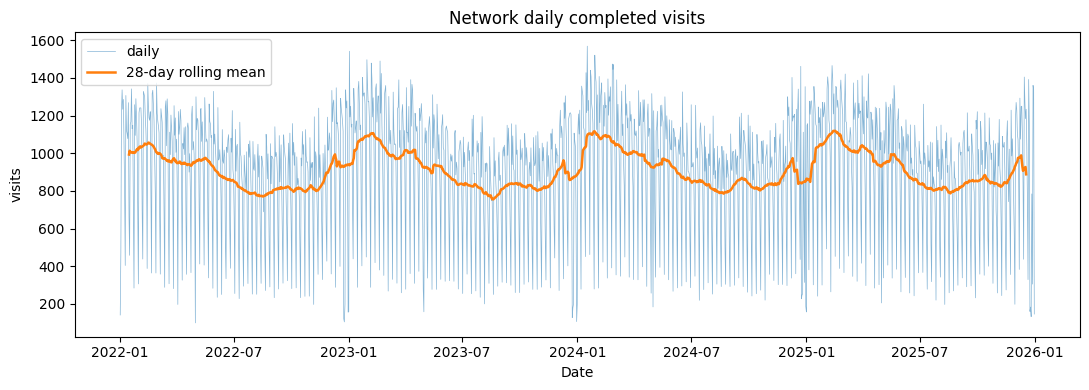

In [4]:
from clinic_forecast.visualization import plot_network_demand

plot_network_demand(usage, title="Network daily completed visits")
plt.show()

In [5]:
daily = usage.groupby("date")["visits"].sum()
yearly = daily.resample("YE").mean()
print("Mean daily visits by year:")
print(yearly.round(0).to_string())
trend_pct = (yearly.iloc[-1] / yearly.iloc[0] - 1) * 100
print(f"\nNet change over the period: {trend_pct:+.0f}%")

Mean daily visits by year:
date
2022-12-31    895.0
2023-12-31    903.0
2024-12-31    916.0
2025-12-31    917.0
Freq: YE-DEC

Net change over the period: +2%


The rolling mean shows growth is neither smooth nor monotonic — there are
sustained surges and slowdowns lasting weeks (the demand-episode process),
and the weekly cycle dominates short-term variation (the wide daily band).

**Modelling consequence:** a single linear trend term will misfit; models need
either local trend estimates (recent-window features) or changepoint-capable
structures. The episodes set a hard ceiling on achievable accuracy — they are
visible only once they have started.

## Demand concentration across clinics

Staffing attention should follow volume. Concentration also matters for
modelling: if a few clinics dominate network error, per-clinic effort should
be allocated unevenly.

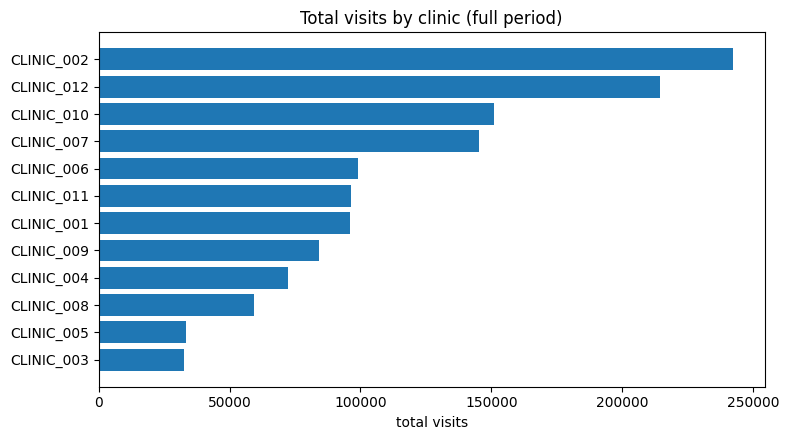

Top 3 clinics carry 46% of network volume.
Largest/smallest clinic ratio: 7.5x


In [6]:
from clinic_forecast.visualization import plot_clinic_ranking

plot_clinic_ranking(usage, title="Total visits by clinic (full period)")
plt.show()

totals = usage.groupby("clinic_id")["visits"].sum().sort_values(ascending=False)
top3_share = totals.head(3).sum() / totals.sum()
print(f"Top 3 clinics carry {top3_share:.0%} of network volume.")
print(f"Largest/smallest clinic ratio: {totals.iloc[0] / totals.iloc[-1]:.1f}x")

**Modelling consequence:** volume-weighted metrics (WAPE at network level) will
be dominated by the large clinics. Per-clinic metrics must be reported
alongside, or small clinics can be badly served by a model that looks good on
average — an equity concern in healthcare operations.

## Weekday structure

The weekly cycle is the strongest calendar effect in outpatient demand:
Mondays peak (weekend backlog), activity decays through the week, and weekend
behaviour splits the network into two regimes (urgent care open, the rest
closed Sundays).

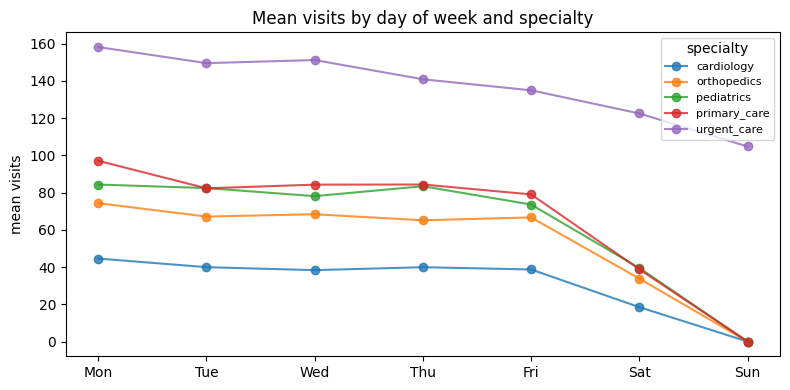

In [7]:
from clinic_forecast.visualization import plot_weekday_profile

plot_weekday_profile(usage, group_col="specialty",
                     title="Mean visits by day of week and specialty")
plt.show()

In [8]:
open_rows = usage[usage["is_open"] == 1].copy()
open_rows["dow"] = open_rows["date"].dt.dayofweek
monday_lift = (
    open_rows[open_rows["dow"] == 0]["visits"].mean()
    / open_rows[open_rows["dow"].between(1, 4)]["visits"].mean() - 1
)
print(f"Monday lift over Tue-Fri (open days): {monday_lift:+.0%}")

Monday lift over Tue-Fri (open days): +12%

Each specialty shows the Monday peak and weekday decay, but the *level* and
exact weekday shape differ by clinic — the profiles are not parallel copies.

**Modelling consequence:** day-of-week must interact with the clinic (or the
model must be flexible enough to learn clinic-specific weekday shapes). A
single shared weekday coefficient leaves systematic error behind.

## Monthly seasonality and holidays

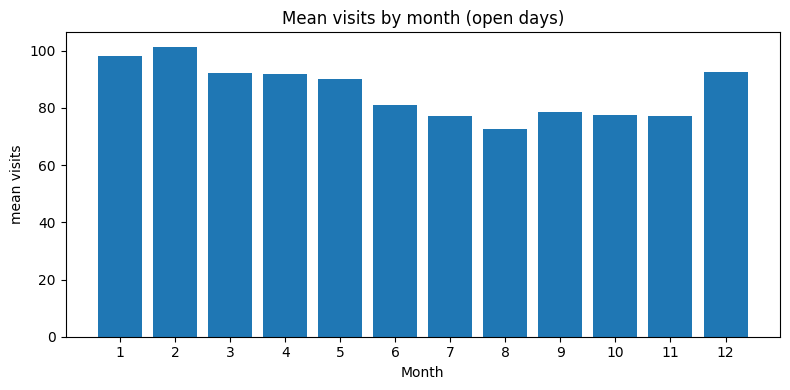

In [9]:
from clinic_forecast.visualization import plot_monthly_profile

plot_monthly_profile(usage[usage["is_open"] == 1],
                     title="Mean visits by month (open days)")
plt.show()

In [10]:
holiday_effect = usage[usage["weekend_open"] == 1].groupby("is_holiday")["visits"].mean()
print("Urgent-care mean visits, holiday vs normal day:")
print(holiday_effect.rename({0: "normal", 1: "holiday"}).round(1).to_string())
print(f"\nHoliday reduction: {1 - holiday_effect[1] / holiday_effect[0]:.0%}")

Urgent-care mean visits, holiday vs normal day:
is_holiday
normal     138.7
holiday     55.9

Holiday reduction: 60%


Winter months run clearly above summer, consistent with respiratory-season
pressure on primary and urgent care. Holidays cut urgent-care demand sharply
even though those clinics stay open, and close everyone else.

**Modelling consequence:** month (or a smooth yearly seasonality term) and an
explicit holiday flag both earn their place as features. Holiday effects are
large enough that a model without the flag will produce its worst errors
exactly on the days operations most needs to plan around.

## Regional differences

Regions matter for two later steps: hierarchical reconciliation (clinic
forecasts must sum to coherent regional totals) and regional staffing budgets.

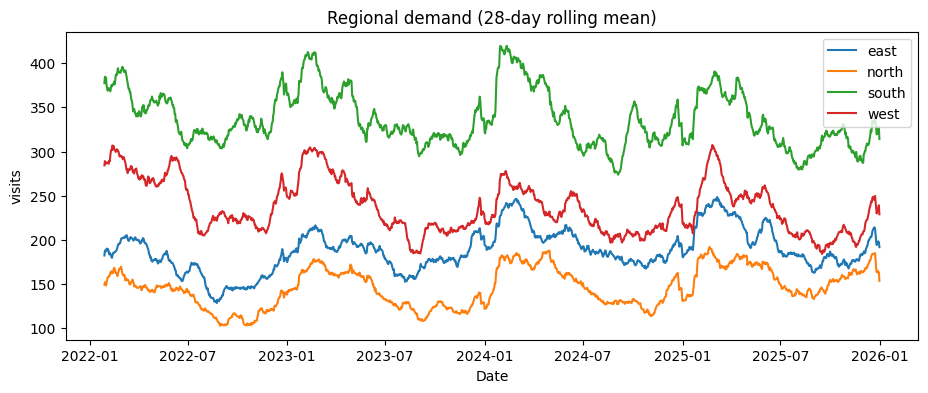

In [11]:
regional = usage.groupby(["region", "date"], as_index=False)["visits"].sum()
fig, ax = plt.subplots()
for region, frame in regional.groupby("region"):
    ax.plot(frame["date"], frame["visits"].rolling(28).mean(), label=region)
ax.set_title("Regional demand (28-day rolling mean)")
ax.set_xlabel("Date")
ax.set_ylabel("visits")
ax.legend()
plt.show()

Regional trajectories diverge over time — they share seasonality but not
growth, because clinic-level trend changepoints do not cancel out within small
regions.

**Modelling consequence:** regional aggregates are not a substitute for
clinic-level modelling; reconciliation (planned in the roadmap) is the right
way to get coherent numbers at every level.

## Marketing and demand

Marketing spend should correlate with demand, but the relationship is
deliberately non-trivial here (as in reality): campaign timing is seasonal
(confounded with winter), effects carry over across days, and returns
diminish at high spend. A scatter plot alone will understate the structure.

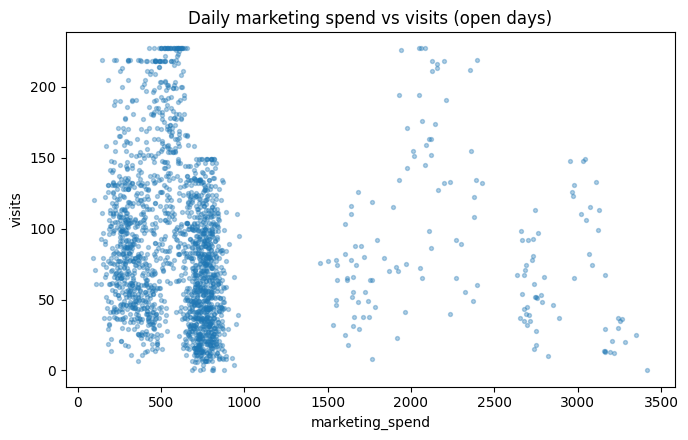

Same-day spend-visits correlation: -0.10
Mean visits on campaign vs non-campaign days: +1%


In [12]:
from clinic_forecast.visualization import plot_spend_vs_demand

open_rows = usage[usage["is_open"] == 1]
plot_spend_vs_demand(open_rows, title="Daily marketing spend vs visits (open days)")
plt.show()

corr_same_day = open_rows["marketing_spend"].corr(open_rows["visits"])
campaign_lift = (
    open_rows[open_rows["campaign_active"] == 1]["visits"].mean()
    / open_rows[open_rows["campaign_active"] == 0]["visits"].mean() - 1
)
print(f"Same-day spend-visits correlation: {corr_same_day:.2f}")
print(f"Mean visits on campaign vs non-campaign days: {campaign_lift:+.0%}")

The raw correlation is positive but weak relative to the campaign-day lift —
consistent with carryover (spend works with a lag) and with confounding
(campaigns cluster in high-season months). Disentangling this is exactly what
the exogenous-variable models in notebook 03 and the feature-based model in
notebook 04 are for.

**Modelling consequence:** include spend and campaign flags as features, but
read their coefficients as *predictive*, not causal. The campaign-day lift
computed above mixes the campaign effect with the season it was launched in.

## Capacity pressure

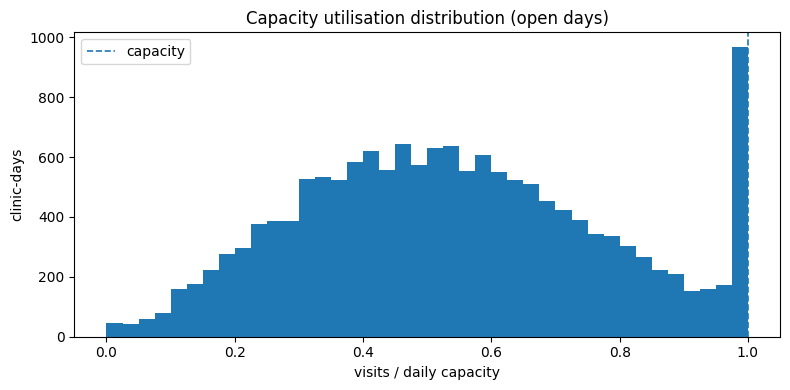

Share of open clinic-days at capacity: 5.4%
95th percentile utilisation: 1.00


In [13]:
from clinic_forecast.visualization import plot_utilization_distribution

plot_utilization_distribution(open_rows)
plt.show()

at_cap = (open_rows["capacity_utilization"] >= 0.999).mean()
p95 = open_rows["capacity_utilization"].quantile(0.95)
print(f"Share of open clinic-days at capacity: {at_cap:.1%}")
print(f"95th percentile utilisation: {p95:.2f}")

Utilisation is mostly comfortable but the right tail matters: a meaningful
share of clinic-days run near or at capacity, where demand is *censored* — we
observe capped visits, not true demand.

**Modelling consequence:** on high-utilisation days the recorded visits
understate demand, so models trained on visits will slightly under-forecast
peaks. This is a known, documented bias; scheduled appointments (less
censored) are the better target for capacity planning, reinforcing the
schedule-vs-realised distinction from notebook 00.

## No-shows and cancellations

In [14]:
ns = usage[usage["is_open"] == 1].groupby("clinic_id").agg(
    mean_no_show_rate=("no_show_rate", "mean"),
    schedule=("scheduled_appointments", "sum"),
    no_shows=("no_show_count", "sum"),
    cancellations=("same_day_cancellations", "sum"),
)
ns["realised_loss"] = (ns["no_shows"] + ns["cancellations"]) / ns["schedule"]
ns.sort_values("realised_loss", ascending=False).round(3)

,mean_no_show_rate,schedule,no_shows,cancellations,realised_loss
clinic_id,,,,,
CLINIC_002,0.130,300958,39565,9252,0.162
CLINIC_003,0.098,37209,3650,1154,0.129
CLINIC_004,0.097,83211,8124,2609,0.129
CLINIC_007,0.088,169286,15266,5519,0.123
CLINIC_008,0.085,67472,5952,2113,0.120
CLINIC_011,0.081,111088,9329,3562,0.116
CLINIC_009,0.081,95115,7628,2972,0.111
CLINIC_005,0.064,36745,2367,1213,0.097
CLINIC_012,0.064,244216,15763,8028,0.097


No-show behaviour differs structurally between clinics — the worst clinic
loses roughly twice the schedule share of the best. Mondays run about two
points higher than midweek (visible in the generator design and recoverable
from the data).

**Modelling consequence:** a no-show model with clinic-level effects is a
worthwhile secondary target: even a simple per-clinic historical rate converts
a schedule forecast into an expected-visits forecast, and the spread between
clinics means one global rate is not enough.

## Forecastability assessment

Two cheap diagnostics set expectations before any model is fit:

- **Lag-7 autocorrelation** of each clinic's series — how much structure the
  weekly cycle provides.
- **The seasonal-naive error floor** — WAPE of "repeat last week" on the final
  28 days. Models are judged by how far below this floor they land.

In [15]:
from clinic_forecast.metrics import compute_metrics
from clinic_forecast.models.baseline import seasonal_naive_forecast

rows = []
cutoff = usage["date"].max() - pd.Timedelta(days=28)
train, test = usage[usage["date"] <= cutoff], usage[usage["date"] > cutoff]
naive = seasonal_naive_forecast(train=train, future=test)
scored = test.merge(naive, on=["clinic_id", "date"])

for clinic_id, frame in usage.groupby("clinic_id"):
    series = frame.sort_values("date")["visits"]
    clinic_scored = scored[scored["clinic_id"] == clinic_id]
    rows.append({
        "clinic_id": clinic_id,
        "lag7_autocorr": series.autocorr(lag=7),
        "cv": series.std() / series.mean(),
        "naive_wape": compute_metrics(
            clinic_scored["visits"], clinic_scored["forecast"]
        ).wape,
    })

forecastability = pd.DataFrame(rows).set_index("clinic_id").round(2)
forecastability.sort_values("naive_wape")

,lag7_autocorr,cv,naive_wape
clinic_id,,,
CLINIC_002,0.30,0.28,36.34
CLINIC_007,0.30,0.30,41.46
CLINIC_011,0.70,0.60,41.56
CLINIC_006,0.71,0.60,41.97
CLINIC_012,0.37,0.31,43.92
CLINIC_001,0.73,0.60,46.95
CLINIC_004,0.67,0.61,47.95
CLINIC_010,0.72,0.59,56.43
CLINIC_003,0.60,0.71,56.55


In [16]:
print(f"Network naive WAPE (final 28 days): "
      f"{compute_metrics(scored['visits'], scored['forecast']).wape:.1f}%")
print(f"Median clinic lag-7 autocorrelation: "
      f"{forecastability['lag7_autocorr'].median():.2f}")

Network naive WAPE (final 28 days): 46.4%
Median clinic lag-7 autocorrelation: 0.67


Lag-7 autocorrelation is high everywhere — the weekly cycle is real and
exploitable — but the naive error floor still sits in the double digits
because of the episode process and overdispersion. Clinics with the highest
coefficient of variation are the hardest and will need the most conservative
staffing buffers.

## Modelling strategy

What this analysis implies for the rest of the project:

1. **Features:** day-of-week x clinic interactions, month or smooth yearly
   seasonality, an explicit holiday flag, the opening calendar, lagged demand
   (1, 7, 14, 28 days) and rolling statistics for local trend, marketing
   spend and campaign flags.
2. **Model class:** a global tree-based model (notebook 04) fits the
   clinic-specific weekday shapes and nonlinear marketing response without
   per-clinic fitting cost; SARIMAX (notebook 03) provides the interpretable
   classical reference.
3. **Evaluation:** WAPE and bias on rolling 28-day folds, always reported per
   clinic as well as pooled; seasonal naive is the floor to beat.
4. **Honest limits:** demand episodes are unforecastable until they begin, and
   capacity censoring biases peak days down. Prediction intervals (roadmap)
   matter more than point accuracy for staffing decisions.